In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

In [3]:
df = pd.read_csv("sample_student_data.csv")
print("Original Dataset:")
print(df)

Original Dataset:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1
5  100     20          50         1


In [4]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [5]:
df_clean = df[(df["Age"] >= lower) & (df["Age"] <= upper)].copy()
print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("\nDataset after Noise Elimination:")
print(df_clean)


Q1: 21.25
Q3: 23.75
IQR: 2.5
Lower Bound: 17.5
Upper Bound: 27.5

Dataset after Noise Elimination:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1


In [6]:
selector = VarianceThreshold(threshold=0.0)
selector.fit_transform(df_clean)
selected_columns = df_clean.columns[selector.get_support()]
print("\nSelected Features:")
print(list(selected_columns))
print("\nRemoved Features:")
print(list(df_clean.columns[~selector.get_support()]))


Selected Features:
['Age', 'Marks', 'Attendance']

Removed Features:
['Constant']


In [7]:
print("\nDataset Information:")
df_clean.info()
print("\nStatistical Summary:")
print(df_clean.describe())
print("\nCorrelation Matrix:")
print(df_clean.corr(numeric_only=True))


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         5 non-null      int64
 1   Marks       5 non-null      int64
 2   Attendance  5 non-null      int64
 3   Constant    5 non-null      int64
dtypes: int64(4)
memory usage: 200.0 bytes

Statistical Summary:
             Age      Marks  Attendance  Constant
count   5.000000   5.000000     5.00000       5.0
mean   22.000000  85.000000    89.80000       1.0
std     1.581139   7.905694     3.49285       0.0
min    20.000000  75.000000    85.00000       1.0
25%    21.000000  80.000000    88.00000       1.0
50%    22.000000  85.000000    90.00000       1.0
75%    23.000000  90.000000    92.00000       1.0
max    24.000000  95.000000    94.00000       1.0

Correlation Matrix:
                 Age     Marks  Attendance  Constant
Age         1.000000  1.000000    0.995893       NaN
Marks  

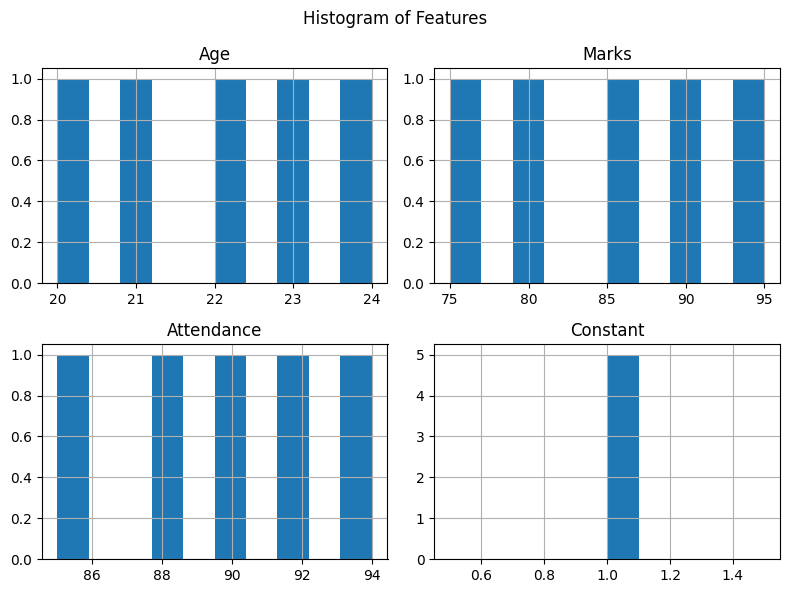

In [8]:
df_clean.hist(figsize=(8, 6))
plt.suptitle("Histogram of Features")
plt.tight_layout()
plt.show()

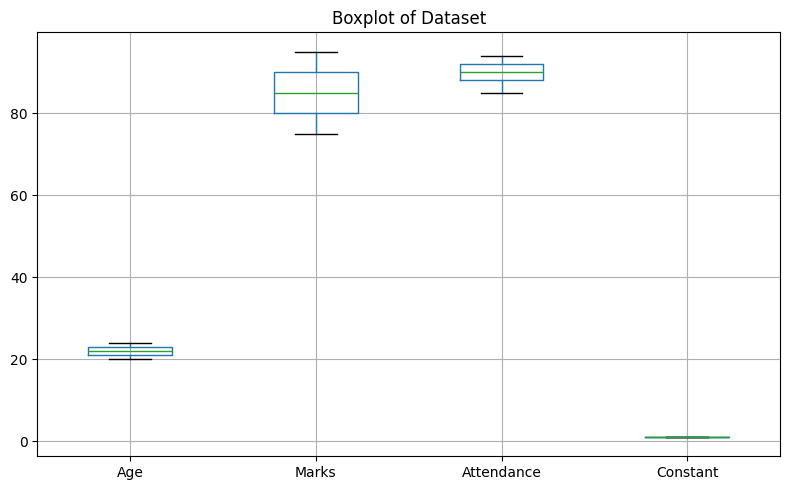

In [9]:
df_clean.boxplot(figsize=(8, 5))
plt.title("Boxplot of Dataset")
plt.tight_layout()
plt.show()